# Import thư viện, Khởi tạo và Metric

In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score, matthews_corrcoef,
    cohen_kappa_score, confusion_matrix
)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [2]:
# Metrics
def gmean_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    per_class = []
    for i in range(cm.shape[0]):
        tp = cm[i,i]
        fn = cm[i].sum() - tp
        fp = cm[:,i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        per_class.append(np.sqrt(sens * spec))
    return np.prod(per_class) ** (1/len(per_class)) if per_class else 0

def gmean_per_class(y_true, y_pred, target_class):
    cm = confusion_matrix(y_true, y_pred)
    i = target_class
    tp = cm[i,i]
    fn = cm[i].sum() - tp
    fp = cm[:,i].sum() - tp
    tn = cm.sum() - tp - fn - fp

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return np.sqrt(recall * specificity)

def print_results(
    version_name,
    phase,
    y_true,
    y_pred,
    time_build_model=None,
    time_predict=None
):
    target_names = ['Excellent', 'Good', 'Average']

    print(f"\n{'='*30} {version_name} - Phase {phase} {'='*30}")
    print(classification_report(
        y_true,
        y_pred,
        digits=10,
        target_names=target_names
    ))

    # Precision / Recall / F1 theo từng class
    prec_per_class = precision_score(y_true, y_pred, average=None)
    rec_per_class  = recall_score(y_true, y_pred, average=None)
    f1_per_class   = f1_score(y_true, y_pred, average=None)

    # G-Mean per class
    gmean_classes = [
        gmean_per_class(y_true, y_pred, i)
        for i in range(len(target_names))
    ]

    print("G-Mean per class (one-vs-rest):")
    for idx, name in enumerate(target_names):
        print(f"  {name:<10}: {gmean_classes[idx]:.10f}")
        
    print()

    # ===== TẠO DICTIONARY METRICS =====
    metrics = {
        'Version': version_name,
        'Phase': phase,

        'TimeBuildModel': time_build_model,
        'TimePredict': time_predict,

        'Accuracy': accuracy_score(y_true, y_pred),
        'BalancedAcc': balanced_accuracy_score(y_true, y_pred),

        'Precision Macro': precision_score(y_true, y_pred, average='macro'),
        'Precision Weighted': precision_score(y_true, y_pred, average='weighted'),

        'Recall Macro': recall_score(y_true, y_pred, average='macro'),
        'Recall Weighted': recall_score(y_true, y_pred, average='weighted'),

        'F1-Score Macro': f1_score(y_true, y_pred, average='macro'),
        'F1-Score Weighted': f1_score(y_true, y_pred, average='weighted'),

        'GMean': gmean_score(y_true, y_pred),

        'MCC': matthews_corrcoef(y_true, y_pred),
        'Kappa': cohen_kappa_score(y_true, y_pred),
    }

    # ===== THÊM METRIC CHO TỪNG CLASS =====
    for i, name in enumerate(target_names):
        metrics[f'Precision_{name}'] = prec_per_class[i]
        metrics[f'Recall_{name}'] = rec_per_class[i]
        metrics[f'F1-Score_{name}'] = f1_per_class[i]
        metrics[f'G-Mean_{name}'] = gmean_classes[i]

    # In ra console
    for k, v in metrics.items():
        if k not in ['Version', 'Phase'] and v is not None:
            print(f"{k:22} : {v:.10f}")

    return metrics

# Chuẩn bị dữ liệu + train

In [3]:
def build_tabular_features(df_features, phase_cols, static_cols):
    phase_blocks = []

    for p in ['1', '2', '3', '4']:
        cols_p = [c for c in phase_cols if f"_p{p}_" in c]

        # đảm bảo thứ tự cột ổn định
        cols_p = sorted(cols_p)

        df_p = df_features[cols_p].copy()
        df_p.columns = [
            f"phase{p}__{c.replace(f'_p{p}_', '_')}"
            for c in cols_p
        ]

        phase_blocks.append(df_p)

    X_phase = pd.concat(phase_blocks, axis=1)
    X_static = df_features[static_cols].copy()

    X_tabular = pd.concat([X_static, X_phase], axis=1)
    return X_tabular

In [4]:
def prepare_and_train_lightgbm(train_path, val_path=None):
    import pandas as pd
    import lightgbm as lgb
    import time
    from sklearn.preprocessing import LabelEncoder

    print(f"Loading train: {train_path}")
    df_train = pd.read_csv(train_path)

    if val_path:
        df_val = pd.read_csv(val_path)
        df = pd.concat([df_train, df_val], ignore_index=True)
        print(f"Combined train + val: {len(df)} samples")
    else:
        df = df_train
        print(f"Only train: {len(df)} samples")

    df = df.drop(columns=['user_id', 'course_id'], errors='ignore')

    y = df['label_3'].values
    df_features = df.drop('label_3', axis=1)

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    print(f"Classes: {le.classes_}")

    # ===== CHỈ XÁC ĐỊNH CỘT =====
    phase_cols = [
        col for col in df_features.columns
        if any(f"_p{p}_" in col for p in ['1', '2', '3', '4'])
    ]
    static_cols = [c for c in df_features.columns if c not in phase_cols]

    for p in ['1', '2', '3', '4']:
        print(f"Phase {p}: {sum(f'_p{p}_' in c for c in phase_cols)} features")

    # ===== BUILD TABULAR =====
    X_final = build_tabular_features(
        df_features,
        phase_cols,
        static_cols
    )

    print(f"Final X shape: {X_final.shape}")

    model = lgb.LGBMClassifier(
        objective='multiclass',
        max_depth=10,
        min_child_samples=20,
        n_estimators=200,
        num_leaves=127,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    start_time = time.time()
    model.fit(X_final, y_enc)
    time_build_model = time.time() - start_time

    print(f"Time Build Model: {time_build_model:.2f}s")

    return model, le, phase_cols, static_cols, time_build_model


In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def run_and_report_lgbm(
    model,
    X,
    y_true,
    label_encoder,
    dataset_name="",
    output_dir="results"
):

    os.makedirs(output_dir, exist_ok=True)

    # ===== Predict =====
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true, y_pred)
    cm_path = f"{output_dir}/confusion_matrix_{dataset_name}.csv"
    pd.DataFrame(cm).to_csv(cm_path, index=False)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.show()
    # ===== Probability matrix (GIỐNG HYBRID) =====
    df_prob = pd.DataFrame(
        y_prob,
        columns=[f"Prob_Class_{i}" for i in range(y_prob.shape[1])]
    )
    df_prob["y_true"] = y_true
    df_prob["y_pred"] = y_pred

    prob_path = f"{output_dir}/probability_matrix_{dataset_name}.csv"
    df_prob.to_csv(prob_path, index=False)

    print(f"Saved confusion matrix to: {cm_path}")
    print(f"Saved probability matrix to: {prob_path}")

    return y_true, y_pred

# Chạy theo từng V

In [6]:
base_path = "/kaggle/input/lo-dataset"

In [7]:
import time

def run_experiment(
    base_path,
    train_file,
    val_file,
    test_prefix,
    version_name
):
    print(f"\n{'#'*5}")
    print(f"Version: {version_name}")
    print(f"{'#'*5}")

    train_path = f"{base_path}/{train_file}"
    val_path   = f"{base_path}/{val_file}"

    test_files = [
        f"{base_path}/{test_prefix}_1.csv",
        f"{base_path}/{test_prefix}_2.csv",
        f"{base_path}/{test_prefix}_3.csv",
        f"{base_path}/{test_prefix}_4.csv",
    ]

    # ===== Train model =====
    start_train = time.perf_counter()

    model, le, phase_cols, static_cols, time_build_model = \
        prepare_and_train_lightgbm(train_path, val_path)

    results = []

    for phase, test_path in enumerate(test_files, 1):
        print(f"\n--- Test Phase {phase}: {test_path} ---")

        df_test = pd.read_csv(test_path)
        df_test = df_test.drop(columns=['user_id', 'course_id'], errors='ignore')

        y_test = df_test['label_3'].values
        df_features = df_test.drop('label_3', axis=1)

        # ===== BUILD TABULAR (FLATTEN) =====
        X_test = build_tabular_features(
            df_features,
            phase_cols,
            static_cols
        )

        # ===== Predict =====
        start_pred = time.perf_counter()
        preds = model.predict(X_test)
        time_predict = time.perf_counter() - start_pred

        y_test_enc = le.transform(y_test)

        # ===== In metrics (GIỮ NGUYÊN) =====
        res = print_results(
            version_name=version_name,
            phase=phase,
            y_true=y_test_enc,
            y_pred=preds,
            time_build_model=time_build_model,
            time_predict=time_predict
        )
        run_and_report_lgbm(
            model=model,
            X=X_test,
            y_true=y_test_enc,
            label_encoder=le,
            dataset_name=f"{version_name}_phase{phase}"
        )

        results.append(res)

    # ===== Tạo dataframe tổng hợp (GIỮ NGUYÊN) =====
    df = pd.DataFrame(results).round(10)

    df = df.rename(columns={
        "PrecMacro": "Precision Macro",
        "PrecWeighted": "Precision Weighted",
        "RecMacro": "Recall Macro",
        "RecWeighted": "Recall Weighted",
        "F1Macro": "F1-Score Macro",
        "F1Weighted": "F1-Score Weighted",
    })

    ordered_cols = [
        "Version",
        "Phase",
        "TimeBuildModel",
        "TimePredict",
        "Accuracy",
        "BalancedAcc",
        "Precision Macro",
        "Precision Weighted",
        "Recall Macro",
        "Recall Weighted",
        "F1-Score Macro",
        "F1-Score Weighted",
        "GMean",
        "MCC",
        "Kappa",

        "Precision_Excellent",
        "Recall_Excellent",
        "F1-Score_Excellent",
        "G-Mean_Excellent",

        "Precision_Good",
        "Recall_Good",
        "F1-Score_Good",
        "G-Mean_Good",

        "Precision_Average",
        "Recall_Average",
        "F1-Score_Average",
        "G-Mean_Average",
    ]

    ordered_cols = [c for c in ordered_cols if c in df.columns]
    df = df[ordered_cols]

    return df


## V0 (Raw)

In [8]:
# base_path = "/kaggle/input/lo-dataset/Raw/Raw"

In [9]:
#df_v0 = run_experiment(
#   base_path=base_path,
#    train_file="train_raw.csv",
#    val_file="val.csv",
#    test_prefix="test",
#    version_name="V0 (Raw)"
#)

#df_v0

In [10]:
#df_v0.to_csv("results_v0.csv", index=False)

## V1 (Median)

In [11]:
base_path = "/kaggle/input/lo-dataset/Median/Median"


#####
Version: V1 (Median)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median.csv
Combined train + val: 2092071 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (2092071, 179)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.115664 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20668
[LightGBM] [Info] Number of data points in the train set: 2092071, number of used features: 178
[LightGBM] [Info] Start training from score -6.949767
[LightGBM] [Info] Start training from score -5.951396
[LightGBM] [Info] Start training from score -0.003567
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

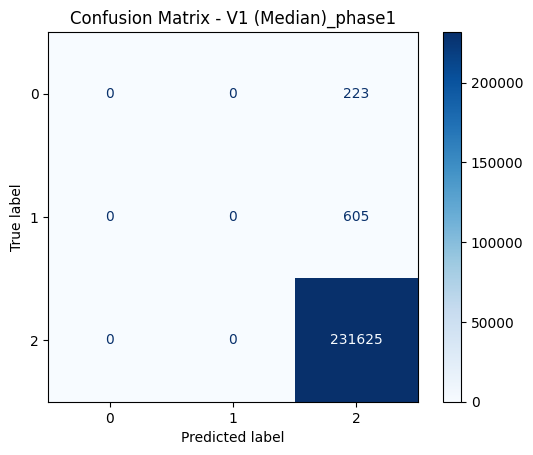

Saved confusion matrix to: results/confusion_matrix_V1 (Median)_phase1.csv
Saved probability matrix to: results/probability_matrix_V1 (Median)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Median/Median/test_2.csv ---

============================== V1 (Median) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.7894736842 0.0247933884 0.0480769231       605
     Average  0.9965151398 0.9999956827 0.9982523774    231625

    accuracy                      0.9964982168    232453
   macro avg  0.5953296080 0.3415963570 0.3487764335    232453
weighted avg  0.9950202872 0.9964982168 0.9948217207    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.0000000000
  Good      : 0.1574578060
  Average   : 0.1474416379

TimeBuildModel         : 17.9732391834
TimePredict            : 0.9172499270
Accuracy               : 0.9964982168
BalancedAcc            : 0.341

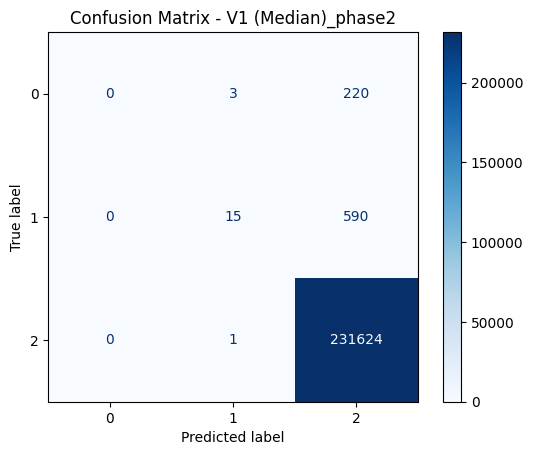

Saved confusion matrix to: results/confusion_matrix_V1 (Median)_phase2.csv
Saved probability matrix to: results/probability_matrix_V1 (Median)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Median/Median/test_3.csv ---

============================== V1 (Median) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.0056097783 0.5515695067 0.0111065962       223
        Good  0.0438871473 0.0462809917 0.0450522928       605
     Average  0.9970984663 0.9035294118 0.9480107086    231625

    accuracy                      0.9009606243    232453
   macro avg  0.3488651307 0.5004599701 0.3347231992    232453
weighted avg  0.9936663969 0.9009606243 0.9447617961    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.7069548771
  Good      : 0.2148469801
  Average   : 0.4888527203

TimeBuildModel         : 17.9732391834
TimePredict            : 1.0461223440
Accuracy               : 0.9009606243
BalancedAcc            : 0.500

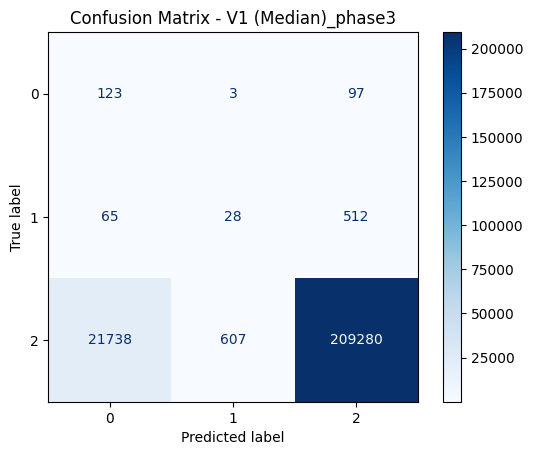

Saved confusion matrix to: results/confusion_matrix_V1 (Median)_phase3.csv
Saved probability matrix to: results/probability_matrix_V1 (Median)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Median/Median/test_4.csv ---

============================== V1 (Median) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.6093189964 0.7623318386 0.6772908367       223
        Good  0.7371134021 0.7090909091 0.7228306655       605
     Average  0.9993004940 0.9991581220 0.9992293029    231625

    accuracy                      0.9981759754    232453
   macro avg  0.7819109641 0.8235269565 0.7997836017    232453
weighted avg  0.9982439833 0.9981759754 0.9982010802    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.8729112376
  Good      : 0.8417974633
  Average   : 0.8964768058

TimeBuildModel         : 17.9732391834
TimePredict            : 1.2097106350
Accuracy               : 0.9981759754
BalancedAcc            : 0.823

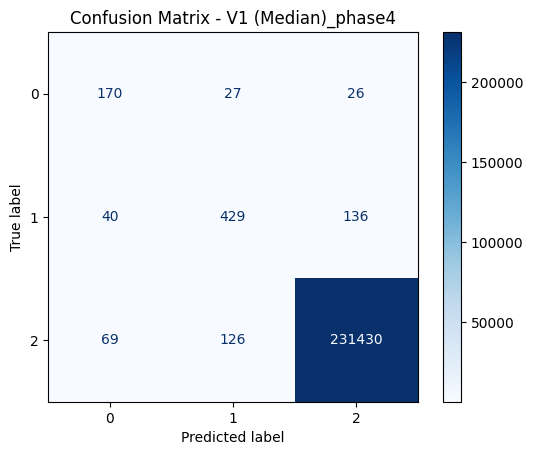

Saved confusion matrix to: results/confusion_matrix_V1 (Median)_phase4.csv
Saved probability matrix to: results/probability_matrix_V1 (Median)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V1 (Median),1,17.973239,0.751848,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V1 (Median),2,17.973239,0.917250,0.996498,0.341596,0.595330,0.995020,0.341596,0.996498,0.348776,0.994822,0.000000,0.131277,0.038828,0.000000,0.000000,0.000000,0.000000,0.789474,0.024793,0.048077,0.157458,0.996515,0.999996,0.998252,0.147442
2,V1 (Median),3,17.973239,1.046122,0.900961,0.500460,0.348865,0.993666,0.500460,0.900961,0.334723,0.944762,0.420307,0.032494,0.011462,0.005610,0.551570,0.011107,0.706955,0.043887,0.046281,0.045052,0.214847,0.997098,0.903529,0.948011,0.488853
3,V1 (Median),4,17.973239,1.209711,0.998176,0.823527,0.781911,0.998244,0.823527,0.998176,0.799784,0.998201,0.870106,0.748388,0.748241,0.609319,0.762332,0.677291,0.872911,0.737113,0.709091,0.722831,0.841797,0.999300,0.999158,0.999229,0.896477


In [12]:
df_v1 = run_experiment(
    base_path=base_path,
    train_file="train_median.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V1 (Median)"
)

df_v1

In [13]:
df_v1.to_csv("results_v1.csv", index=False)

## V2 (Median_CDSMOTE)


#####
Version: V2 (Median CDSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_cdsmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (5791443, 179)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.481140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38015
[LightGBM] [Info] Number of data points in the train set: 5791443, number of used features: 178
[LightGBM] [Info] Start training from score -1.139457
[LightGBM] [Info] Start training from score -1.139251
[LightGBM] [Info] Start training from score -1.021794
Time Build Model: 135.27s

--- Test Phase 1: /kaggle/input/lo-dataset/Median/Median/test_1.csv ---

============================== V2 (Median CDSMOTE) - Phase 1 ==============================

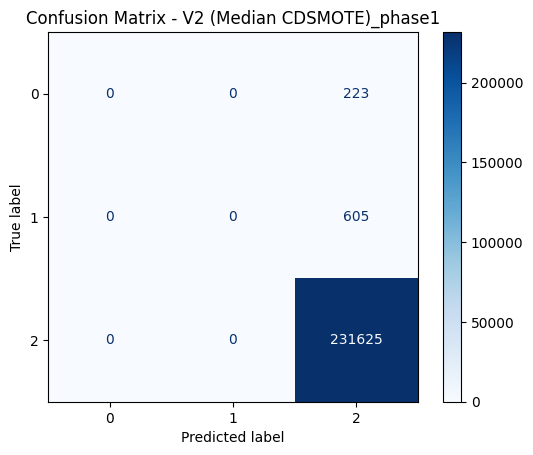

Saved confusion matrix to: results/confusion_matrix_V2 (Median CDSMOTE)_phase1.csv
Saved probability matrix to: results/probability_matrix_V2 (Median CDSMOTE)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Median/Median/test_2.csv ---

============================== V2 (Median CDSMOTE) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  0.8888888889 0.0358744395 0.0689655172       223
        Good  1.0000000000 0.0479338843 0.0914826498       605
     Average  0.9966009079 1.0000000000 0.9982975606    231625

    accuracy                      0.9965971616    232453
   macro avg  0.9618299322 0.3612694413 0.3862485759    232453
weighted avg  0.9965064228 0.9965971616 0.9950458750    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.1894050817
  Good      : 0.2189380833
  Average   : 0.2142281956

TimeBuildModel         : 135.2728323936
TimePredict            : 0.7474253710
Accuracy               : 0.9965971616
Balan

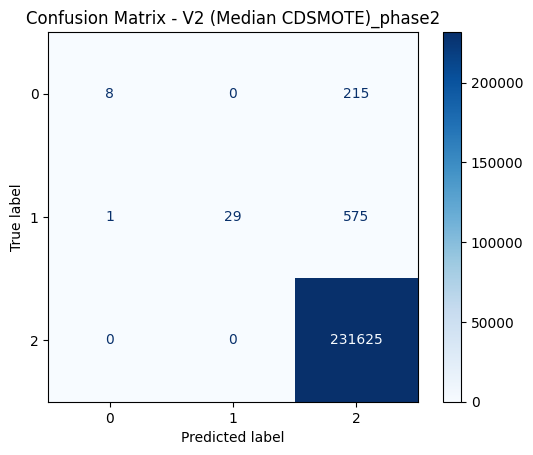

Saved confusion matrix to: results/confusion_matrix_V2 (Median CDSMOTE)_phase2.csv
Saved probability matrix to: results/probability_matrix_V2 (Median CDSMOTE)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Median/Median/test_3.csv ---

============================== V2 (Median CDSMOTE) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.3509615385 0.6547085202 0.4569640063       223
        Good  0.7827160494 0.5239669421 0.6277227723       605
     Average  0.9985278373 0.9985580140 0.9985429254    231625

    accuracy                      0.9969929405    232453
   macro avg  0.7107351417 0.7257444921 0.6944099013    232453
weighted avg  0.9973449168 0.9969929405 0.9970582455    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.8086700993
  Good      : 0.7237182226
  Average   : 0.7663655307

TimeBuildModel         : 135.2728323936
TimePredict            : 0.8794887840
Accuracy               : 0.9969929405
Balan

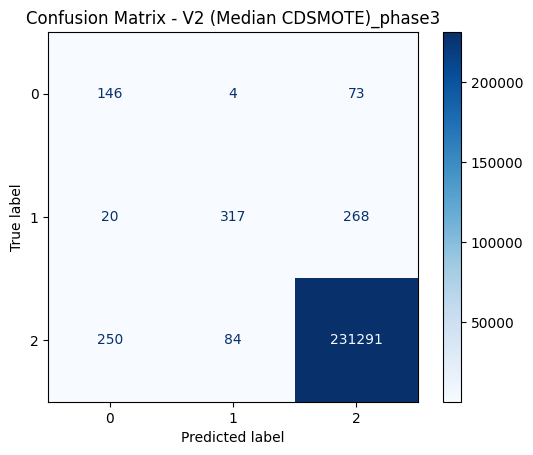

Saved confusion matrix to: results/confusion_matrix_V2 (Median CDSMOTE)_phase3.csv
Saved probability matrix to: results/probability_matrix_V2 (Median CDSMOTE)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Median/Median/test_4.csv ---

============================== V2 (Median CDSMOTE) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.4882629108 0.9327354260 0.6409861325       223
        Good  0.5575692964 0.8644628099 0.6779001944       605
     Average  0.9997403598 0.9974268753 0.9985822776    231625

    accuracy                      0.9970187522    232453
   macro avg  0.6818575223 0.9315417038 0.7724895348    232453
weighted avg  0.9980988539 0.9970187522 0.9974045918    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.9653288789
  Good      : 0.9289324254
  Average   : 0.9618469554

TimeBuildModel         : 135.2728323936
TimePredict            : 0.9141376890
Accuracy               : 0.9970187522
Balan

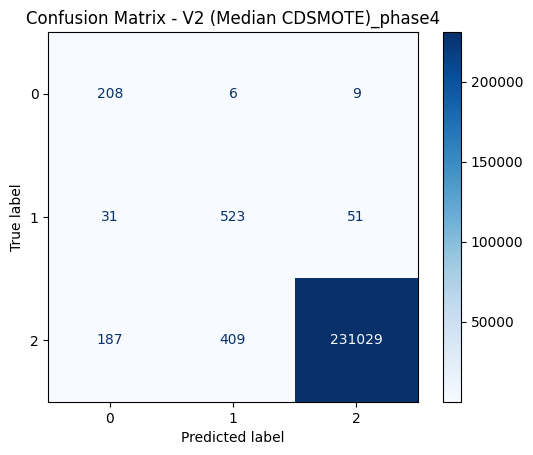

Saved confusion matrix to: results/confusion_matrix_V2 (Median CDSMOTE)_phase4.csv
Saved probability matrix to: results/probability_matrix_V2 (Median CDSMOTE)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V2 (Median CDSMOTE),1,135.272832,0.714235,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V2 (Median CDSMOTE),2,135.272832,0.747425,0.996597,0.361269,0.961830,0.996506,0.361269,0.996597,0.386249,0.995046,0.207108,0.211107,0.086374,0.888889,0.035874,0.068966,0.189405,1.000000,0.047934,0.091483,0.218938,0.996601,1.000000,0.998298,0.214228
2,V2 (Median CDSMOTE),3,135.272832,0.879489,0.996993,0.725744,0.710735,0.997345,0.725744,0.996993,0.694410,0.997058,0.765465,0.575041,0.574978,0.350962,0.654709,0.456964,0.808670,0.782716,0.523967,0.627723,0.723718,0.998528,0.998558,0.998543,0.766366
3,V2 (Median CDSMOTE),4,135.272832,0.914138,0.997019,0.931542,0.681858,0.998099,0.931542,0.997019,0.772490,0.997405,0.951894,0.704263,0.682735,0.488263,0.932735,0.640986,0.965329,0.557569,0.864463,0.677900,0.928932,0.999740,0.997427,0.998582,0.961847


In [14]:
df_v2 = run_experiment(
    base_path=base_path,
    train_file="train_median_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V2 (Median CDSMOTE)"
)

df_v2

In [15]:
df_v2.to_csv("results_v2.csv", index=False)

## V3 (Median SASMOTE)


#####
Version: V3 (Median SASMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_sasmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (5791443, 179)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.514086 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 37998
[LightGBM] [Info] Number of data points in the train set: 5791443, number of used features: 178
[LightGBM] [Info] Start training from score -1.139457
[LightGBM] [Info] Start training from score -1.139251
[LightGBM] [Info] Start training from score -1.021794
Time Build Model: 136.73s

--- Test Phase 1: /kaggle/input/lo-dataset/Median/Median/test_1.csv ---

============================== V3 (Median SASMOTE) - Phase 1 ==============================

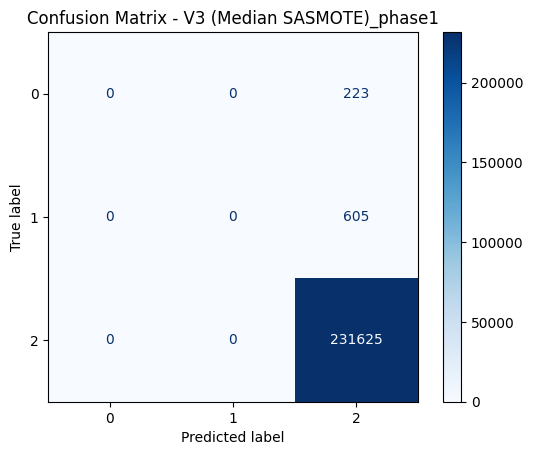

Saved confusion matrix to: results/confusion_matrix_V3 (Median SASMOTE)_phase1.csv
Saved probability matrix to: results/probability_matrix_V3 (Median SASMOTE)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Median/Median/test_2.csv ---

============================== V3 (Median SASMOTE) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  0.9000000000 0.0403587444 0.0772532189       223
        Good  0.8524590164 0.0859504132 0.1561561562       605
     Average  0.9967080066 0.9999654614 0.9983340769    231625

    accuracy                      0.9966659927    232453
   macro avg  0.9163890077 0.3754248730 0.4105811506    232453
weighted avg  0.9962397979 0.9966659927 0.9952585361    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.2008944265
  Good      : 0.2931673187
  Average   : 0.2758338786

TimeBuildModel         : 136.7338240147
TimePredict            : 0.7332753010
Accuracy               : 0.9966659927
Balan

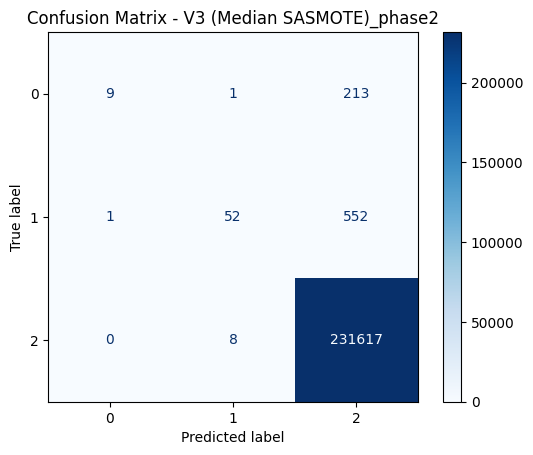

Saved confusion matrix to: results/confusion_matrix_V3 (Median SASMOTE)_phase2.csv
Saved probability matrix to: results/probability_matrix_V3 (Median SASMOTE)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Median/Median/test_3.csv ---

============================== V3 (Median SASMOTE) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.3293269231 0.6143497758 0.4287949922       223
        Good  0.7715736041 0.5024793388 0.6086086086       605
     Average  0.9984372504 0.9985148408 0.9984760441    231625

    accuracy                      0.9968552783    232453
   macro avg  0.6997792592 0.7051146518 0.6786265483    232453
weighted avg  0.9972048976 0.9968552783 0.9969148310    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.7833337085
  Good      : 0.7087201731
  Average   : 0.7496439701

TimeBuildModel         : 136.7338240147
TimePredict            : 0.8686076990
Accuracy               : 0.9968552783
Balan

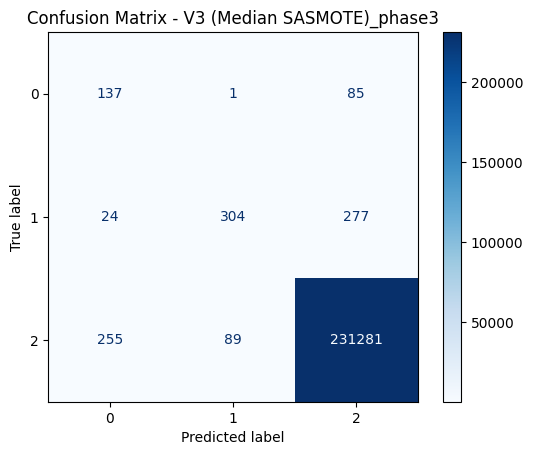

Saved confusion matrix to: results/confusion_matrix_V3 (Median SASMOTE)_phase3.csv
Saved probability matrix to: results/probability_matrix_V3 (Median SASMOTE)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Median/Median/test_4.csv ---

============================== V3 (Median SASMOTE) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.4738041002 0.9327354260 0.6283987915       223
        Good  0.5560253700 0.8694214876 0.6782720825       605
     Average  0.9997533194 0.9973491635 0.9985497944    231625

    accuracy                      0.9969542230    232453
   macro avg  0.6765275965 0.9331686924 0.7684068895    232453
weighted avg  0.9980938782 0.9969542230 0.9973611167    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.9653018340
  Good      : 0.9315827945
  Average   : 0.9636861880

TimeBuildModel         : 136.7338240147
TimePredict            : 0.9493238090
Accuracy               : 0.9969542230
Balan

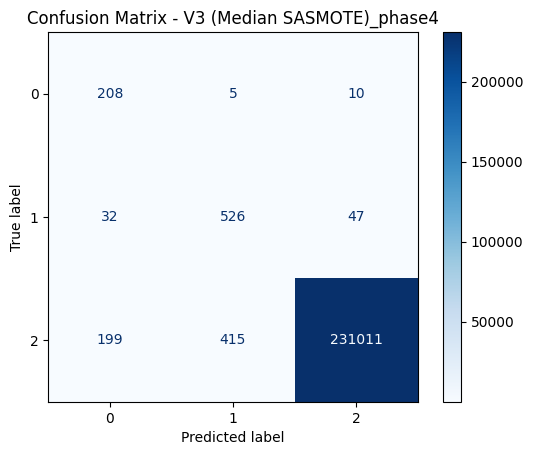

Saved confusion matrix to: results/confusion_matrix_V3 (Median SASMOTE)_phase4.csv
Saved probability matrix to: results/probability_matrix_V3 (Median SASMOTE)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V3 (Median SASMOTE),1,136.733824,0.666639,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V3 (Median SASMOTE),2,136.733824,0.733275,0.996666,0.375425,0.916389,0.996240,0.375425,0.996666,0.410581,0.995259,0.253266,0.255241,0.137527,0.900000,0.040359,0.077253,0.200894,0.852459,0.085950,0.156156,0.293167,0.996708,0.999965,0.998334,0.275834
2,V3 (Median SASMOTE),3,136.733824,0.868608,0.996855,0.705115,0.699779,0.997205,0.705115,0.996855,0.678627,0.996915,0.746607,0.552639,0.552547,0.329327,0.614350,0.428795,0.783334,0.771574,0.502479,0.608609,0.708720,0.998437,0.998515,0.998476,0.749644
3,V3 (Median SASMOTE),4,136.733824,0.949324,0.996954,0.933169,0.676528,0.998094,0.933169,0.996954,0.768407,0.997361,0.953396,0.701687,0.678938,0.473804,0.932735,0.628399,0.965302,0.556025,0.869421,0.678272,0.931583,0.999753,0.997349,0.998550,0.963686


In [16]:
df_v3 = run_experiment(
    base_path=base_path,
    train_file="train_median_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V3 (Median SASMOTE)"
)

df_v3

In [17]:
df_v3.to_csv("results_v3.csv", index=False)

## V4 (Median RadiusSMOTE)


#####
Version: V4 (Median RadiusSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_radiussmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (5791443, 179)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.239174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38597
[LightGBM] [Info] Number of data points in the train set: 5791443, number of used features: 178
[LightGBM] [Info] Start training from score -1.139457
[LightGBM] [Info] Start training from score -1.139251
[LightGBM] [Info] Start training from score -1.021794
Time Build Model: 130.00s

--- Test Phase 1: /kaggle/input/lo-dataset/Median/Median/test_1.csv ---

============================== V4 (Median RadiusSMOTE) - Phase 1 ==============================
              precision    recall  f1-score   suppo

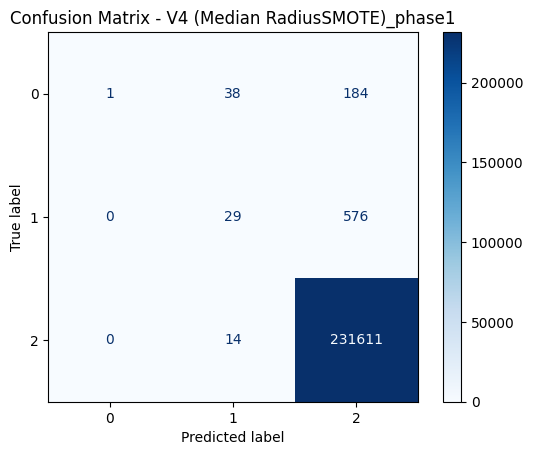

Saved confusion matrix to: results/confusion_matrix_V4 (Median RadiusSMOTE)_phase1.csv
Saved probability matrix to: results/probability_matrix_V4 (Median RadiusSMOTE)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Median/Median/test_2.csv ---

============================== V4 (Median RadiusSMOTE) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  1.0000000000 0.0134529148 0.0265486726       223
        Good  0.6433566434 0.3041322314 0.4130190797       605
     Average  0.9974026981 0.9997236913 0.9985618460    231625

    accuracy                      0.9969671288    232453
   macro avg  0.8802531138 0.4391029458 0.4793765328    232453
weighted avg  0.9964837224 0.9969671288 0.9961053825    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.1159867010
  Good      : 0.5513605267
  Average   : 0.5212140122

TimeBuildModel         : 130.0042200089
TimePredict            : 0.9417491610
Accuracy               : 0.9969

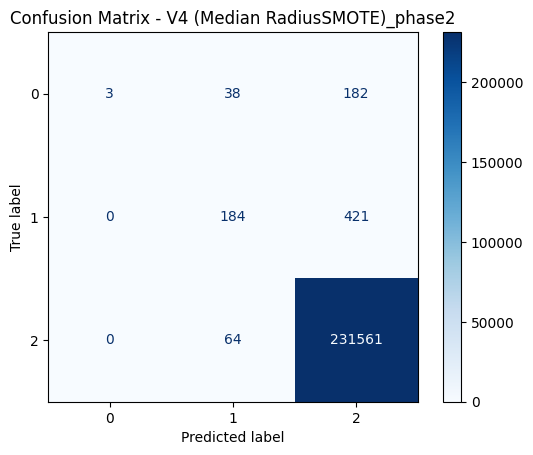

Saved confusion matrix to: results/confusion_matrix_V4 (Median RadiusSMOTE)_phase2.csv
Saved probability matrix to: results/probability_matrix_V4 (Median RadiusSMOTE)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Median/Median/test_3.csv ---

============================== V4 (Median RadiusSMOTE) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.5636363636 0.4170403587 0.4793814433       223
        Good  0.5425667090 0.7057851240 0.6135057471       605
     Average  0.9989805660 0.9984457636 0.9987130932    231625

    accuracy                      0.9971263008    232453
   macro avg  0.7017278795 0.7070904154 0.6972000945    232453
weighted avg  0.9973750279 0.9971263008 0.9972123107    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.6456865034
  Good      : 0.8394576953
  Average   : 0.8449050858

TimeBuildModel         : 130.0042200089
TimePredict            : 1.0140717580
Accuracy               : 0.9971

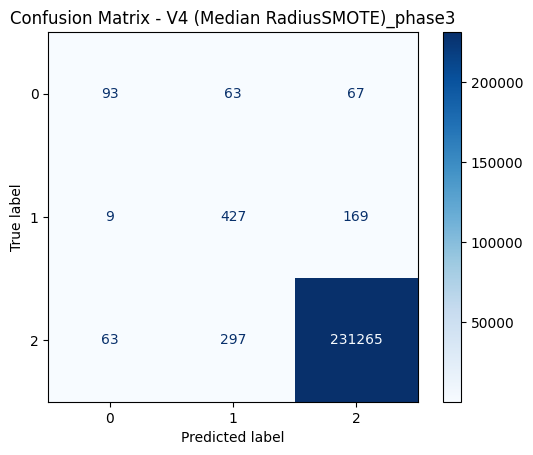

Saved confusion matrix to: results/confusion_matrix_V4 (Median RadiusSMOTE)_phase3.csv
Saved probability matrix to: results/probability_matrix_V4 (Median RadiusSMOTE)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Median/Median/test_4.csv ---

============================== V4 (Median RadiusSMOTE) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.5987055016 0.8295964126 0.6954887218       223
        Good  0.6271428571 0.7256198347 0.6727969349       605
     Average  0.9994123849 0.9986314085 0.9990217441    231625

    accuracy                      0.9977586867    232453
   macro avg  0.7417535812 0.8512825519 0.7891024669    232453
weighted avg  0.9980590760 0.9977586867 0.9978814969    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.9105786329
  Good      : 0.8513536147
  Average   : 0.9135671807

TimeBuildModel         : 130.0042200089
TimePredict            : 1.0650192110
Accuracy               : 0.9977

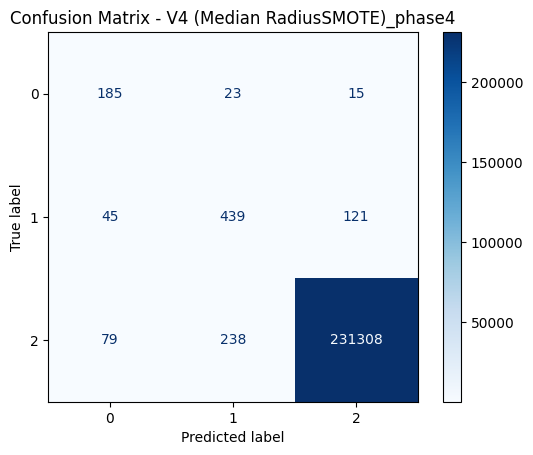

Saved confusion matrix to: results/confusion_matrix_V4 (Median RadiusSMOTE)_phase4.csv
Saved probability matrix to: results/probability_matrix_V4 (Median RadiusSMOTE)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V4 (Median RadiusSMOTE),1,130.00422,0.821060,0.996507,0.350786,0.784918,0.995070,0.350786,0.996507,0.363936,0.995004,0.161355,0.187384,0.107198,1.000000,0.004484,0.008929,0.066965,0.358025,0.047934,0.084548,0.218914,0.996729,0.999940,0.998332,0.286567
1,V4 (Median RadiusSMOTE),2,130.00422,0.941749,0.996967,0.439103,0.880253,0.996484,0.439103,0.996967,0.479377,0.996105,0.321825,0.420161,0.367840,1.000000,0.013453,0.026549,0.115987,0.643357,0.304132,0.413019,0.551361,0.997403,0.999724,0.998562,0.521214
2,V4 (Median RadiusSMOTE),3,130.00422,1.014072,0.997126,0.707090,0.701728,0.997375,0.707090,0.997126,0.697200,0.997212,0.770802,0.625079,0.623535,0.563636,0.417040,0.479381,0.645687,0.542567,0.705785,0.613506,0.839458,0.998981,0.998446,0.998713,0.844905
3,V4 (Median RadiusSMOTE),4,130.00422,1.065019,0.997759,0.851283,0.741754,0.998059,0.851283,0.997759,0.789102,0.997881,0.891366,0.719021,0.715501,0.598706,0.829596,0.695489,0.910579,0.627143,0.725620,0.672797,0.851354,0.999412,0.998631,0.999022,0.913567


In [18]:
df_v4 = run_experiment(
    base_path=base_path,
    train_file="train_median_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V4 (Median RadiusSMOTE)"
)

df_v4

In [19]:
df_v4.to_csv("results_v4.csv", index=False)

## V5 (Mean)

In [20]:
base_path = "/kaggle/input/lo-dataset/Mean/Mean"


#####
Version: V5 (Mean)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean.csv
Combined train + val: 2092071 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (2092071, 179)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.106495 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20725
[LightGBM] [Info] Number of data points in the train set: 2092071, number of used features: 178
[LightGBM] [Info] Start training from score -6.949767
[LightGBM] [Info] Start training from score -5.951396
[LightGBM] [Info] Start training from score -0.003567
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

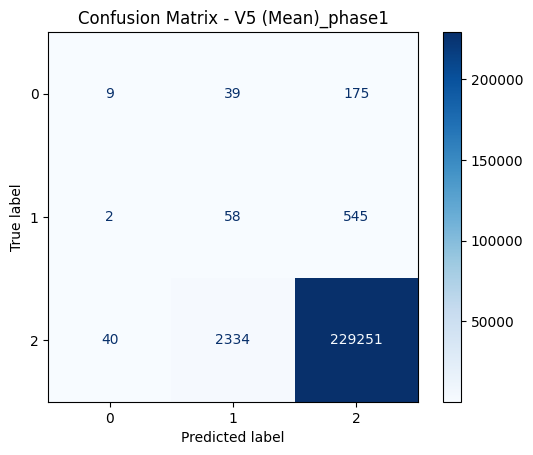

Saved confusion matrix to: results/confusion_matrix_V5 (Mean)_phase1.csv
Saved probability matrix to: results/probability_matrix_V5 (Mean)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Mean/Mean/test_2.csv ---

============================== V5 (Mean) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  0.1002331002 0.1928251121 0.1319018405       223
        Good  0.1263157895 0.2776859504 0.1736434109       605
     Average  0.9975898810 0.9935801403 0.9955809733    231625

    accuracy                      0.9909487079    232453
   macro avg  0.4080462569 0.4880304009 0.4337087416    232453
weighted avg  0.9944613716 0.9909487079 0.9926131791    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.4387534715
  Good      : 0.5256369612
  Average   : 0.5713085647

TimeBuildModel         : 18.8734796047
TimePredict            : 1.0228356030
Accuracy               : 0.9909487079
BalancedAcc            : 0.4880304009
Pr

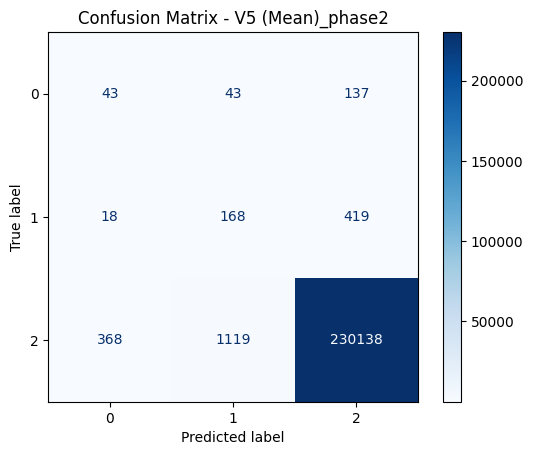

Saved confusion matrix to: results/confusion_matrix_V5 (Mean)_phase2.csv
Saved probability matrix to: results/probability_matrix_V5 (Mean)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Mean/Mean/test_3.csv ---

============================== V5 (Mean) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.2277691108 0.6547085202 0.3379629630       223
        Good  0.3671428571 0.4247933884 0.3938697318       605
     Average  0.9983903908 0.9961791689 0.9972835542    231625

    accuracy                      0.9943644522    232453
   macro avg  0.5311007862 0.6918936925 0.5763720830    232453
weighted avg  0.9960081746 0.9943644522 0.9950805546    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.8082778013
  Good      : 0.6511387878
  Average   : 0.7406891466

TimeBuildModel         : 18.8734796047
TimePredict            : 1.2712568100
Accuracy               : 0.9943644522
BalancedAcc            : 0.6918936925
Pr

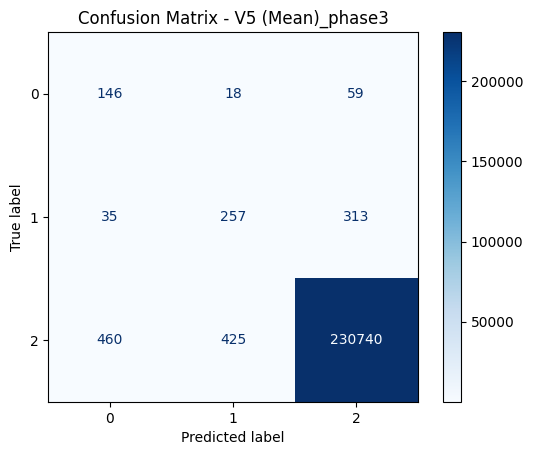

Saved confusion matrix to: results/confusion_matrix_V5 (Mean)_phase3.csv
Saved probability matrix to: results/probability_matrix_V5 (Mean)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Mean/Mean/test_4.csv ---

============================== V5 (Mean) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.5754385965 0.7354260090 0.6456692913       223
        Good  0.6462264151 0.6793388430 0.6623690572       605
     Average  0.9991836981 0.9987825148 0.9989830662    231625

    accuracy                      0.9976984595    232453
   macro avg  0.7402829032 0.8045157889 0.7690071383    232453
weighted avg  0.9978585515 0.9976984595 0.9977680230    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.8573463863
  Good      : 0.8238201075
  Average   : 0.8779519061

TimeBuildModel         : 18.8734796047
TimePredict            : 1.3285560100
Accuracy               : 0.9976984595
BalancedAcc            : 0.8045157889
Pr

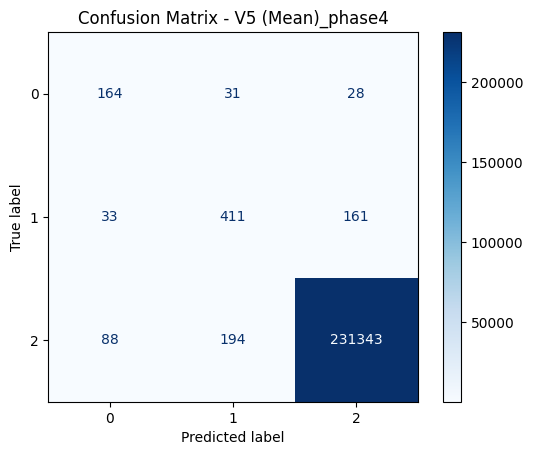

Saved confusion matrix to: results/confusion_matrix_V5 (Mean)_phase4.csv
Saved probability matrix to: results/probability_matrix_V5 (Mean)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V5 (Mean),1,18.87348,0.932502,0.986513,0.375326,0.399066,0.993550,0.375326,0.986513,0.365733,0.989921,0.281188,0.056104,0.048496,0.176471,0.040359,0.065693,0.200877,0.023858,0.095868,0.038208,0.308037,0.996869,0.989751,0.993297,0.359302
1,V5 (Mean),2,18.87348,1.022836,0.990949,0.488030,0.408046,0.994461,0.488030,0.990949,0.433709,0.992613,0.508853,0.196799,0.183503,0.100233,0.192825,0.131902,0.438753,0.126316,0.277686,0.173643,0.525637,0.997590,0.993580,0.995581,0.571309
2,V5 (Mean),3,18.87348,1.271257,0.994364,0.691894,0.531101,0.996008,0.691894,0.994364,0.576372,0.995081,0.730505,0.405635,0.394020,0.227769,0.654709,0.337963,0.808278,0.367143,0.424793,0.393870,0.651139,0.998390,0.996179,0.997284,0.740689
3,V5 (Mean),4,18.87348,1.328556,0.997698,0.804516,0.740283,0.997859,0.804516,0.997698,0.769007,0.997768,0.852746,0.694186,0.693197,0.575439,0.735426,0.645669,0.857346,0.646226,0.679339,0.662369,0.823820,0.999184,0.998783,0.998983,0.877952


In [21]:
df_v5 = run_experiment(
    base_path=base_path,
    train_file="train_mean.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V5 (Mean)"
)

df_v5

In [22]:
df_v5.to_csv("results_v5.csv", index=False)

## V6 (Mean CDSMOTE)


#####
Version: V6 (Mean CDSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_cdsmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (5791443, 179)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.502712 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38809
[LightGBM] [Info] Number of data points in the train set: 5791443, number of used features: 179
[LightGBM] [Info] Start training from score -1.139457
[LightGBM] [Info] Start training from score -1.139251
[LightGBM] [Info] Start training from score -1.021794
Time Build Model: 132.62s

--- Test Phase 1: /kaggle/input/lo-dataset/Mean/Mean/test_1.csv ---

============================== V6 (Mean CDSMOTE) - Phase 1 ==============================
             

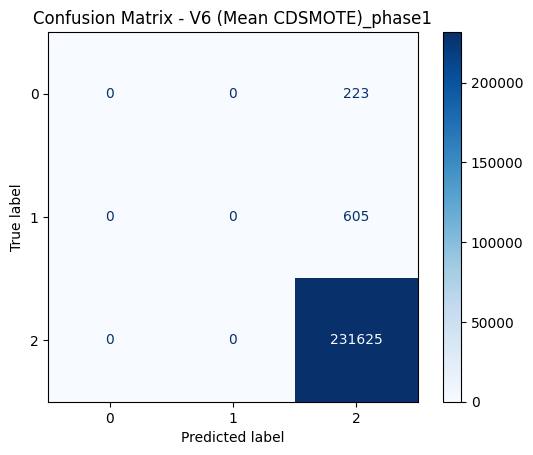

Saved confusion matrix to: results/confusion_matrix_V6 (Mean CDSMOTE)_phase1.csv
Saved probability matrix to: results/probability_matrix_V6 (Mean CDSMOTE)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Mean/Mean/test_2.csv ---

============================== V6 (Mean CDSMOTE) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  1.0000000000 0.0066115702 0.0131362890       605
     Average  0.9964551364 1.0000000000 0.9982244211    231625

    accuracy                      0.9964551974    232453
   macro avg  0.6654850455 0.3355371901 0.3371202367    232453
weighted avg  0.9955084295 0.9964551974 0.9947029249    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.0000000000
  Good      : 0.0813115628
  Average   : 0.0695048047

TimeBuildModel         : 132.6196627617
TimePredict            : 0.7953750330
Accuracy               : 0.9964551974
BalancedAcc    

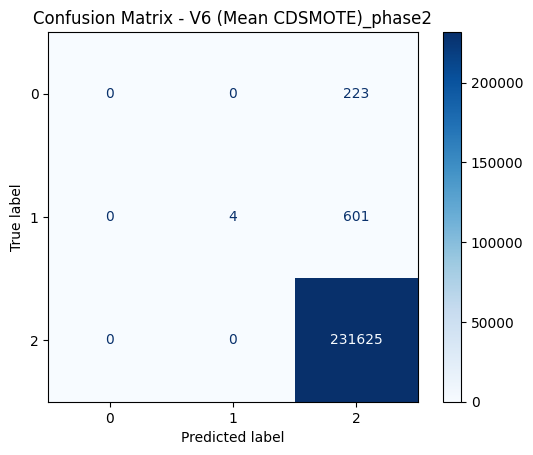

Saved confusion matrix to: results/confusion_matrix_V6 (Mean CDSMOTE)_phase2.csv
Saved probability matrix to: results/probability_matrix_V6 (Mean CDSMOTE)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Mean/Mean/test_3.csv ---

============================== V6 (Mean CDSMOTE) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.2198795181 0.3273542601 0.2630630631       223
        Good  0.6333333333 0.1884297521 0.2904458599       605
     Average  0.9972794806 0.9986400432 0.9979592981    231625

    accuracy                      0.9958873407    232453
   macro avg  0.6168307773 0.5048080184 0.5171560737    232453
weighted avg  0.9955864604 0.9958873407 0.9954128587    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.5718296691
  Good      : 0.4340231698
  Average   : 0.4874414228

TimeBuildModel         : 132.6196627617
TimePredict            : 0.8482871020
Accuracy               : 0.9958873407
BalancedAcc    

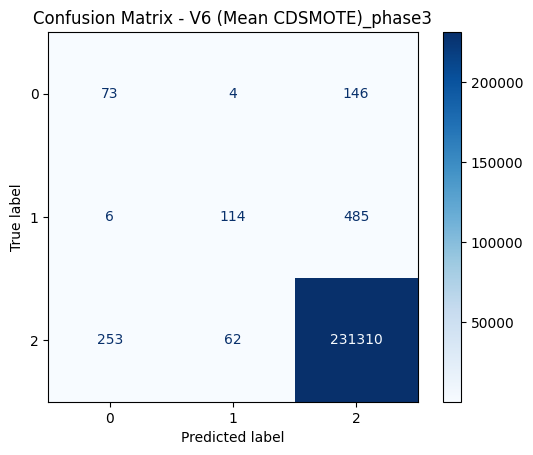

Saved confusion matrix to: results/confusion_matrix_V6 (Mean CDSMOTE)_phase3.csv
Saved probability matrix to: results/probability_matrix_V6 (Mean CDSMOTE)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Mean/Mean/test_4.csv ---

============================== V6 (Mean CDSMOTE) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.4635761589 0.9417040359 0.6213017751       223
        Good  0.5590128755 0.8611570248 0.6779440468       605
     Average  0.9997706303 0.9973664328 0.9985670844    231625

    accuracy                      0.9969585249    232453
   macro avg  0.6741198883 0.9334091645 0.7659376355    232453
weighted avg  0.9981090909 0.9969585249 0.9973706830    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.9699065207
  Good      : 0.9271625750
  Average   : 0.9661911533

TimeBuildModel         : 132.6196627617
TimePredict            : 0.9213932970
Accuracy               : 0.9969585249
BalancedAcc    

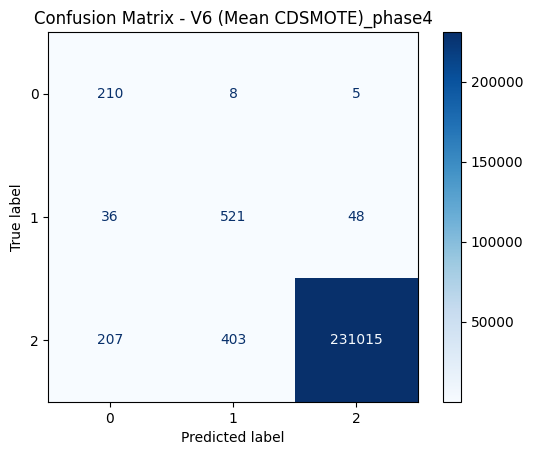

Saved confusion matrix to: results/confusion_matrix_V6 (Mean CDSMOTE)_phase4.csv
Saved probability matrix to: results/probability_matrix_V6 (Mean CDSMOTE)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V6 (Mean CDSMOTE),1,132.619663,0.650686,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V6 (Mean CDSMOTE),2,132.619663,0.795375,0.996455,0.335537,0.665485,0.995508,0.335537,0.996455,0.337120,0.994703,0.000000,0.069390,0.009586,0.000000,0.000000,0.000000,0.000000,1.000000,0.006612,0.013136,0.081312,0.996455,1.000000,0.998224,0.069505
2,V6 (Mean CDSMOTE),3,132.619663,0.848287,0.995887,0.504808,0.616831,0.995586,0.504808,0.995887,0.517156,0.995413,0.494577,0.293549,0.285174,0.219880,0.327354,0.263063,0.571830,0.633333,0.188430,0.290446,0.434023,0.997279,0.998640,0.997959,0.487441
3,V6 (Mean CDSMOTE),4,132.619663,0.921393,0.996959,0.933409,0.674120,0.998109,0.933409,0.996959,0.765938,0.997371,0.954222,0.702158,0.679395,0.463576,0.941704,0.621302,0.969907,0.559013,0.861157,0.677944,0.927163,0.999771,0.997366,0.998567,0.966191


In [23]:
df_v6 = run_experiment(
    base_path=base_path,
    train_file="train_mean_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V6 (Mean CDSMOTE)"
)

df_v6

In [24]:
df_v6.to_csv("results_v6.csv", index=False)

## V7 (Mean SASMOTE)


#####
Version: V7 (Mean SASMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_sasmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (5791443, 179)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.560783 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38784
[LightGBM] [Info] Number of data points in the train set: 5791443, number of used features: 179
[LightGBM] [Info] Start training from score -1.139457
[LightGBM] [Info] Start training from score -1.139251
[LightGBM] [Info] Start training from score -1.021794
Time Build Model: 131.12s

--- Test Phase 1: /kaggle/input/lo-dataset/Mean/Mean/test_1.csv ---

============================== V7 (Mean SASMOTE) - Phase 1 ==============================
             

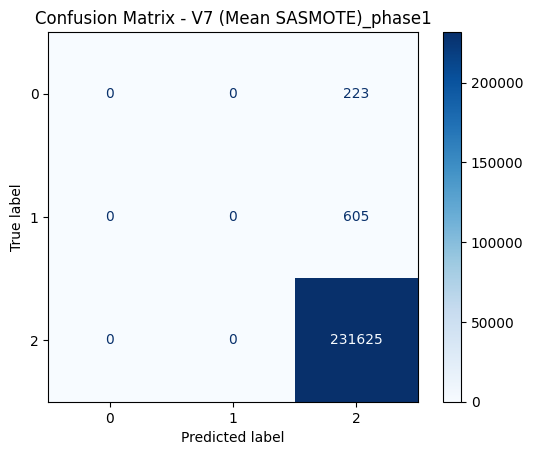

Saved confusion matrix to: results/confusion_matrix_V7 (Mean SASMOTE)_phase1.csv
Saved probability matrix to: results/probability_matrix_V7 (Mean SASMOTE)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Mean/Mean/test_2.csv ---

============================== V7 (Mean SASMOTE) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  1.0000000000 0.0044843049 0.0089285714       223
        Good  1.0000000000 0.0099173554 0.0196399345       605
     Average  0.9964679969 1.0000000000 0.9982308742    231625

    accuracy                      0.9964681032    232453
   macro avg  0.9988226656 0.3381338868 0.3422664600    232453
weighted avg  0.9964805779 0.9964681032 0.9947348473    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.0669649530
  Good      : 0.0995859195
  Average   : 0.0919462141

TimeBuildModel         : 131.1200065613
TimePredict            : 0.7776510560
Accuracy               : 0.9964681032
BalancedAcc    

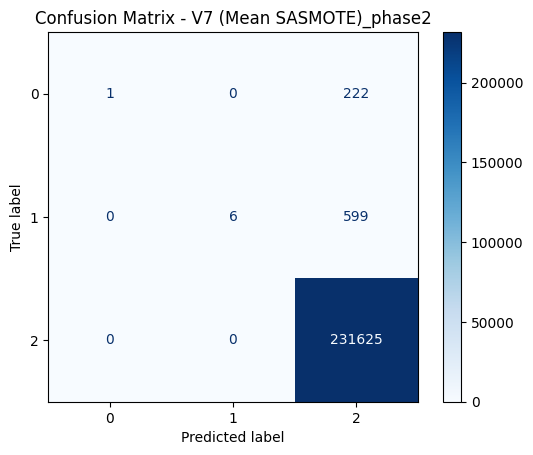

Saved confusion matrix to: results/confusion_matrix_V7 (Mean SASMOTE)_phase2.csv
Saved probability matrix to: results/probability_matrix_V7 (Mean SASMOTE)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Mean/Mean/test_3.csv ---

============================== V7 (Mean SASMOTE) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.2225352113 0.3542600897 0.2733564014       223
        Good  0.7105263158 0.2231404959 0.3396226415       605
     Average  0.9973912069 0.9986098219 0.9980001424    231625

    accuracy                      0.9959733796    232453
   macro avg  0.6434842446 0.5253368025 0.5369930618    232453
weighted avg  0.9959012448 0.9959733796 0.9955914235    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.5948437272
  Good      : 0.4723214599
  Average   : 0.5186031851

TimeBuildModel         : 131.1200065613
TimePredict            : 0.8829122270
Accuracy               : 0.9959733796
BalancedAcc    

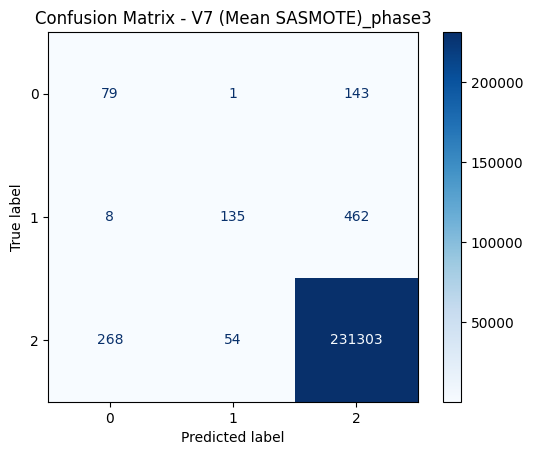

Saved confusion matrix to: results/confusion_matrix_V7 (Mean SASMOTE)_phase3.csv
Saved probability matrix to: results/probability_matrix_V7 (Mean SASMOTE)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Mean/Mean/test_4.csv ---

============================== V7 (Mean SASMOTE) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.4502164502 0.9327354260 0.6072992701       223
        Good  0.5533262936 0.8661157025 0.6752577320       605
     Average  0.9997662783 0.9972584997 0.9985108144    231625

    accuracy                      0.9968552783    232453
   macro avg  0.6677696740 0.9320365427 0.7603559388    232453
weighted avg  0.9980771377 0.9968552783 0.9972941887    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.9652539836
  Good      : 0.9298040112
  Average   : 0.9655153556

TimeBuildModel         : 131.1200065613
TimePredict            : 0.9315011180
Accuracy               : 0.9968552783
BalancedAcc    

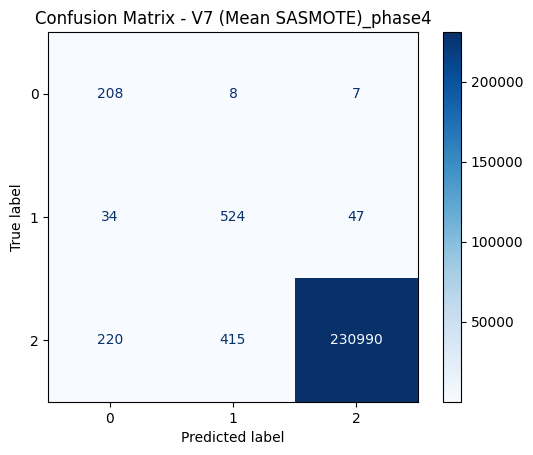

Saved confusion matrix to: results/confusion_matrix_V7 (Mean SASMOTE)_phase4.csv
Saved probability matrix to: results/probability_matrix_V7 (Mean SASMOTE)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V7 (Mean SASMOTE),1,131.120007,0.656429,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V7 (Mean SASMOTE),2,131.120007,0.777651,0.996468,0.338134,0.998823,0.996481,0.338134,0.996468,0.342266,0.994735,0.084956,0.091806,0.016718,1.000000,0.004484,0.008929,0.066965,1.000000,0.009917,0.019640,0.099586,0.996468,1.000000,0.998231,0.091946
2,V7 (Mean SASMOTE),3,131.120007,0.882912,0.995973,0.525337,0.643484,0.995901,0.525337,0.995973,0.536993,0.995591,0.526209,0.323956,0.316900,0.222535,0.354260,0.273356,0.594844,0.710526,0.223140,0.339623,0.472321,0.997391,0.998610,0.998000,0.518603
3,V7 (Mean SASMOTE),4,131.120007,0.931501,0.996855,0.932037,0.667770,0.998077,0.932037,0.996855,0.760356,0.997294,0.953376,0.696118,0.672061,0.450216,0.932735,0.607299,0.965254,0.553326,0.866116,0.675258,0.929804,0.999766,0.997258,0.998511,0.965515


In [25]:
df_v7 = run_experiment(
    base_path=base_path,
    train_file="train_mean_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V7 (Mean SASMOTE)"
)

df_v7

In [26]:
df_v7.to_csv("results_v7.csv", index=False)

## V8 (Mean RadiusSMOTE)


#####
Version: V8 (Mean RadiusSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_radiussmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (5791443, 179)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.447601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39000
[LightGBM] [Info] Number of data points in the train set: 5791443, number of used features: 179
[LightGBM] [Info] Start training from score -1.139457
[LightGBM] [Info] Start training from score -1.139251
[LightGBM] [Info] Start training from score -1.021794
Time Build Model: 122.63s

--- Test Phase 1: /kaggle/input/lo-dataset/Mean/Mean/test_1.csv ---

============================== V8 (Mean RadiusSMOTE) - Phase 1 ==============================
 

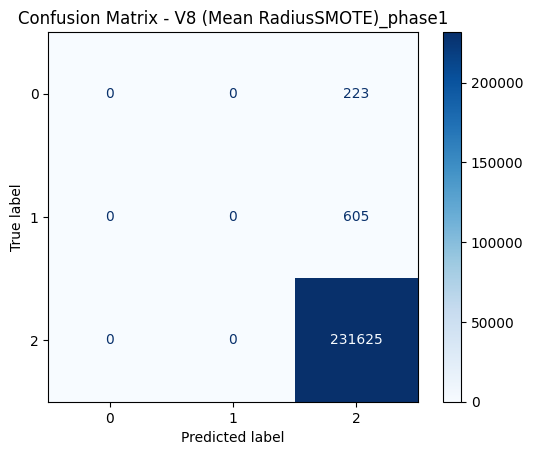

Saved confusion matrix to: results/confusion_matrix_V8 (Mean RadiusSMOTE)_phase1.csv
Saved probability matrix to: results/probability_matrix_V8 (Mean RadiusSMOTE)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Mean/Mean/test_2.csv ---

============================== V8 (Mean RadiusSMOTE) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.5000000000 0.0016528926 0.0032948929       605
     Average  0.9964465629 1.0000000000 0.9982201191    231625

    accuracy                      0.9964422916    232453
   macro avg  0.4988155210 0.3338842975 0.3338383373    232453
weighted avg  0.9941985483 0.9964422916 0.9946730242    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.0000000000
  Good      : 0.0406556937
  Average   : 0.0491473187

TimeBuildModel         : 122.6325035095
TimePredict            : 0.9584360130
Accuracy               : 0.9964422916
Bal

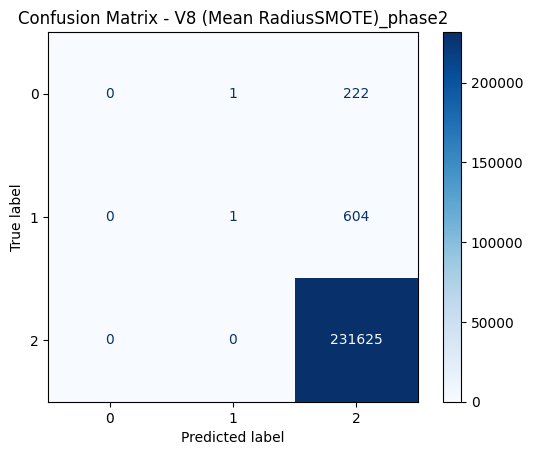

Saved confusion matrix to: results/confusion_matrix_V8 (Mean RadiusSMOTE)_phase2.csv
Saved probability matrix to: results/probability_matrix_V8 (Mean RadiusSMOTE)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Mean/Mean/test_3.csv ---

============================== V8 (Mean RadiusSMOTE) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.6407185629 0.4798206278 0.5487179487       223
        Good  0.5858585859 0.2876033058 0.3858093126       605
     Average  0.9977886883 0.9993567188 0.9985720880    231625

    accuracy                      0.9970058463    232453
   macro avg  0.7414552790 0.5889268841 0.6443664498    232453
weighted avg  0.9963740180 0.9970058463 0.9965457044    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.6926013710
  Good      : 0.5361443150
  Average   : 0.6165955369

TimeBuildModel         : 122.6325035095
TimePredict            : 0.9857735510
Accuracy               : 0.9970058463
Bal

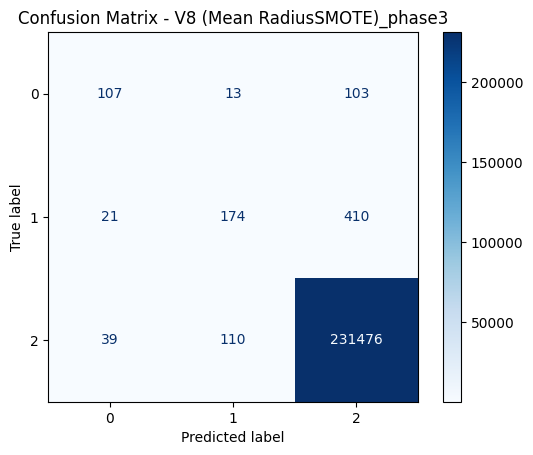

Saved confusion matrix to: results/confusion_matrix_V8 (Mean RadiusSMOTE)_phase3.csv
Saved probability matrix to: results/probability_matrix_V8 (Mean RadiusSMOTE)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Mean/Mean/test_4.csv ---

============================== V8 (Mean RadiusSMOTE) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.5414201183 0.8206278027 0.6524064171       223
        Good  0.5460048426 0.7454545455 0.6303284416       605
     Average  0.9995244045 0.9980744738 0.9987989130    231625

    accuracy                      0.9972467553    232453
   macro avg  0.6956497885 0.8547189407 0.7605112572    232453
weighted avg  0.9979045649 0.9972467553 0.9975075975    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.9055827303
  Good      : 0.8626985674
  Average   : 0.9303117966

TimeBuildModel         : 122.6325035095
TimePredict            : 1.0458873650
Accuracy               : 0.9972467553
Bal

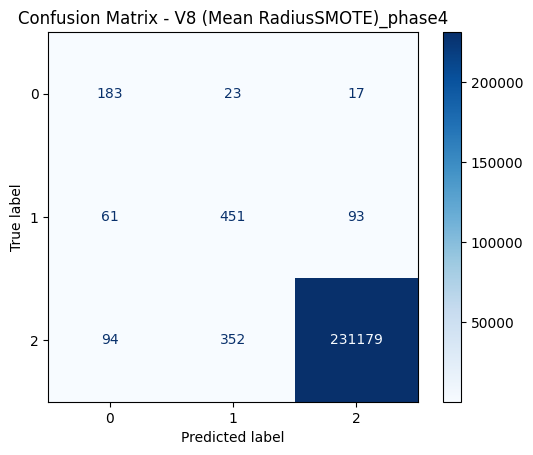

Saved confusion matrix to: results/confusion_matrix_V8 (Mean RadiusSMOTE)_phase4.csv
Saved probability matrix to: results/probability_matrix_V8 (Mean RadiusSMOTE)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V8 (Mean RadiusSMOTE),1,122.632504,0.821147,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V8 (Mean RadiusSMOTE),2,122.632504,0.958436,0.996442,0.333884,0.498816,0.994199,0.333884,0.996442,0.333838,0.994673,0.000000,0.036762,0.003600,0.000000,0.000000,0.000000,0.000000,0.500000,0.001653,0.003295,0.040656,0.996447,1.000000,0.998220,0.049147
2,V8 (Mean RadiusSMOTE),3,122.632504,0.985774,0.997006,0.588927,0.741455,0.996374,0.588927,0.997006,0.644366,0.996546,0.611770,0.479744,0.460220,0.640719,0.479821,0.548718,0.692601,0.585859,0.287603,0.385809,0.536144,0.997789,0.999357,0.998572,0.616596
3,V8 (Mean RadiusSMOTE),4,122.632504,1.045887,0.997247,0.854719,0.695650,0.997905,0.854719,0.997247,0.760511,0.997508,0.899094,0.687560,0.677644,0.541420,0.820628,0.652406,0.905583,0.546005,0.745455,0.630328,0.862699,0.999524,0.998074,0.998799,0.930312


In [27]:
df_v8 = run_experiment(
    base_path=base_path,
    train_file="train_mean_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V8 (Mean RadiusSMOTE)"
)

df_v8

In [28]:
df_v8.to_csv("results_v8.csv", index=False)

## V9 (MissForest)

In [29]:
base_path = "/kaggle/input/lo-dataset/Extra_trees/Extra_trees"


#####
Version: V9 (MissForest)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra.csv
Combined train + val: 2092071 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (2092071, 179)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.121953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20691
[LightGBM] [Info] Number of data points in the train set: 2092071, number of used features: 178
[LightGBM] [Info] Start training from score -6.949767
[LightGBM] [Info] Start training from score -5.951396
[LightGBM] [Info] Start training from score -0.003567
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

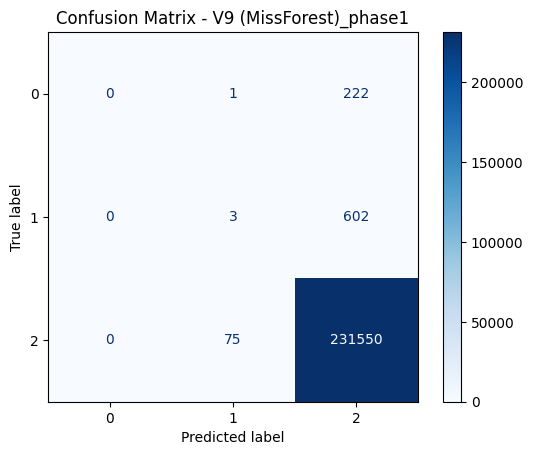

Saved confusion matrix to: results/confusion_matrix_V9 (MissForest)_phase1.csv
Saved probability matrix to: results/probability_matrix_V9 (MissForest)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_2.csv ---

============================== V9 (MissForest) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0320480721 0.2115702479 0.0556642748       605
     Average  0.9970585532 0.9834301133 0.9901974422    231625

    accuracy                      0.9804777740    232453
   macro avg  0.3430355418 0.3983334538 0.3486205723    232453
weighted avg  0.9935904310 0.9804777740 0.9868152247    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.0000000000
  Good      : 0.4561166229
  Average   : 0.4304462038

TimeBuildModel         : 26.5292406082
TimePredict            : 0.7979896480
Accuracy               : 0.9804777740
Balanced

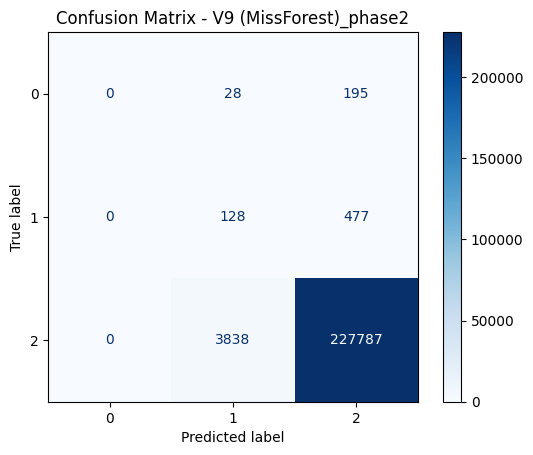

Saved confusion matrix to: results/confusion_matrix_V9 (MissForest)_phase2.csv
Saved probability matrix to: results/probability_matrix_V9 (MissForest)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_3.csv ---

============================== V9 (MissForest) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.0455279303 0.6322869955 0.0849397590       223
        Good  0.0369194591 0.5190082645 0.0689352360       605
     Average  0.9987140651 0.9522590394 0.9749334771    231625

    accuracy                      0.9508244677    232453
   macro avg  0.3603871515 0.7011847665 0.3762694907    232453
weighted avg  0.9952964012 0.9508244677 0.9717216557    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.7900878217
  Good      : 0.7075818875
  Average   : 0.7909733176

TimeBuildModel         : 26.5292406082
TimePredict            : 1.0408877170
Accuracy               : 0.9508244677
Balanced

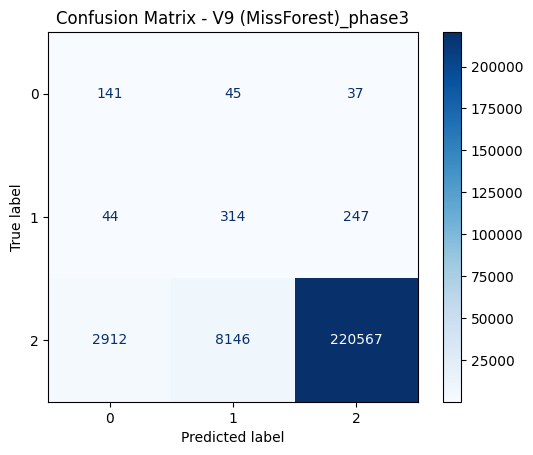

Saved confusion matrix to: results/confusion_matrix_V9 (MissForest)_phase3.csv
Saved probability matrix to: results/probability_matrix_V9 (MissForest)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_4.csv ---

============================== V9 (MissForest) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.6134751773 0.7757847534 0.6851485149       223
        Good  0.7032590051 0.6776859504 0.6902356902       605
     Average  0.9992270757 0.9990674582 0.9991472605    231625

    accuracy                      0.9980168034    232453
   macro avg  0.7719870860 0.8175127207 0.7915104885    232453
weighted avg  0.9980867017 0.9980168034 0.9980420340    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.8805797120
  Good      : 0.8229096401
  Average   : 0.8849211736

TimeBuildModel         : 26.5292406082
TimePredict            : 1.1710035500
Accuracy               : 0.9980168034
Balanced

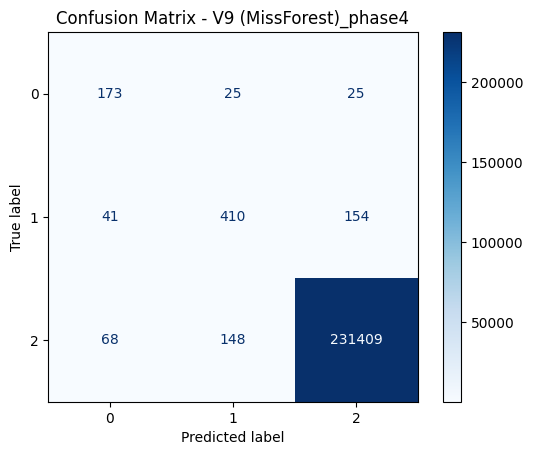

Saved confusion matrix to: results/confusion_matrix_V9 (MissForest)_phase4.csv
Saved probability matrix to: results/probability_matrix_V9 (MissForest)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V9 (MissForest),1,26.529241,0.641627,0.996128,0.334878,0.344810,0.993003,0.334878,0.996128,0.335611,0.994530,0.000000,0.012753,0.007185,0.000000,0.000000,0.000000,0.000000,0.037975,0.004959,0.008772,0.070406,0.996454,0.999676,0.998062,0.069494
1,V9 (MissForest),2,26.529241,0.797990,0.980478,0.398333,0.343036,0.993590,0.398333,0.980478,0.348621,0.986815,0.000000,0.072039,0.054067,0.000000,0.000000,0.000000,0.000000,0.032048,0.211570,0.055664,0.456117,0.997059,0.983430,0.990197,0.430446
2,V9 (MissForest),3,26.529241,1.040888,0.950824,0.701185,0.360387,0.995296,0.701185,0.950824,0.376269,0.971722,0.761853,0.153776,0.075429,0.045528,0.632287,0.084940,0.790088,0.036919,0.519008,0.068935,0.707582,0.998714,0.952259,0.974933,0.790973
3,V9 (MissForest),4,26.529241,1.171004,0.998017,0.817513,0.771987,0.998087,0.817513,0.998017,0.791510,0.998042,0.862333,0.727095,0.726917,0.613475,0.775785,0.685149,0.880580,0.703259,0.677686,0.690236,0.822910,0.999227,0.999067,0.999147,0.884921


In [30]:
df_v9 = run_experiment(
    base_path=base_path,
    train_file="train_extra.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V9 (MissForest)"
)

df_v9

In [31]:
df_v9.to_csv("results_v9.csv", index=False)

## V10 (MissForest CDSMOTE)


#####
Version: V10 (MissForest CDSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_cdsmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (5791443, 179)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.472485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 43212
[LightGBM] [Info] Number of data points in the train set: 5791443, number of used features: 179
[LightGBM] [Info] Start training from score -1.139457
[LightGBM] [Info] Start training from score -1.139251
[LightGBM] [Info] Start training from score -1.021794
Time Build Model: 170.85s

--- Test Phase 1: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_1.csv ---

============================== V10 (MissForest CDSMOTE) - Phase 1 =

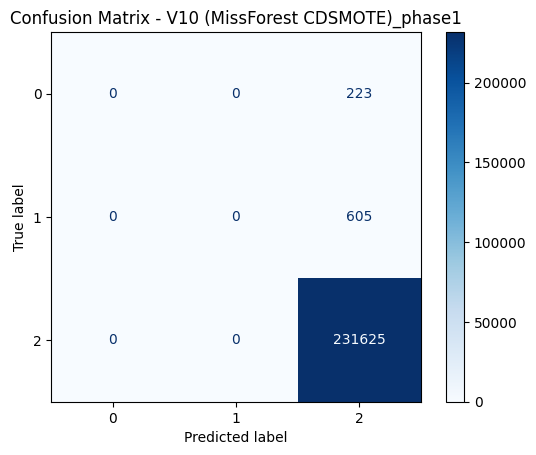

Saved confusion matrix to: results/confusion_matrix_V10 (MissForest CDSMOTE)_phase1.csv
Saved probability matrix to: results/probability_matrix_V10 (MissForest CDSMOTE)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_2.csv ---

============================== V10 (MissForest CDSMOTE) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0166666667 0.0016528926 0.0030075188       605
     Average  0.9964413730 0.9997452779 0.9980905913    231625

    accuracy                      0.9961884768    232453
   macro avg  0.3377026799 0.3337993902 0.3336993700    232453
weighted avg  0.9929354164 0.9961884768 0.9945432099    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.0000000000
  Good      : 0.0406506081
  Average   : 0.0347479760

TimeBuildModel         : 170.8453748226
TimePredict            : 0.5940196090
Accuracy          

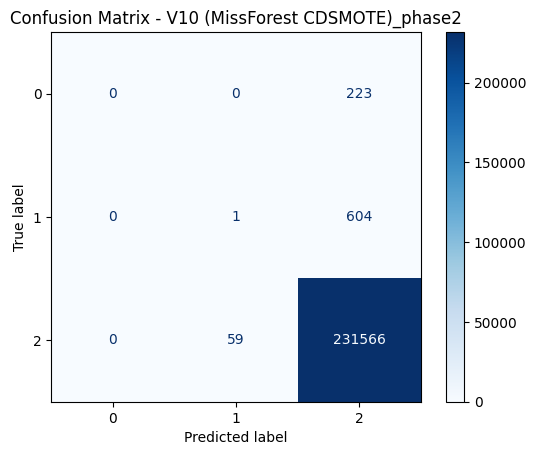

Saved confusion matrix to: results/confusion_matrix_V10 (MissForest CDSMOTE)_phase2.csv
Saved probability matrix to: results/probability_matrix_V10 (MissForest CDSMOTE)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_3.csv ---

============================== V10 (MissForest CDSMOTE) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.2420382166 0.0628099174 0.0997375328       605
     Average  0.9965991519 0.9994819212 0.9980384549    231625

    accuracy                      0.9960852301    232453
   macro avg  0.4128791228 0.3540972795 0.3659253292    232453
weighted avg  0.9936792026 0.9960852301 0.9947430161    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.0000000000
  Good      : 0.2505547427
  Average   : 0.2141726949

TimeBuildModel         : 170.8453748226
TimePredict            : 0.7068558090
Accuracy          

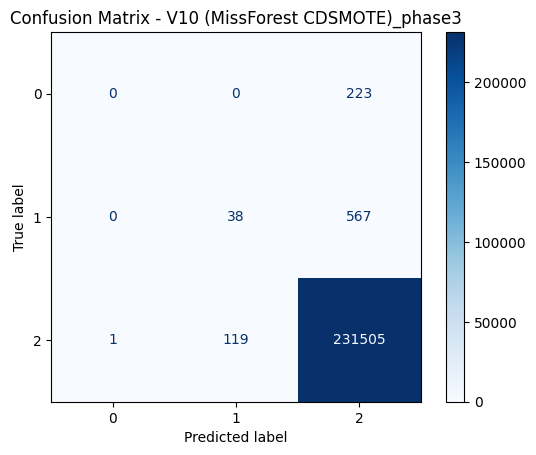

Saved confusion matrix to: results/confusion_matrix_V10 (MissForest CDSMOTE)_phase3.csv
Saved probability matrix to: results/probability_matrix_V10 (MissForest CDSMOTE)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_4.csv ---

============================== V10 (MissForest CDSMOTE) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.5189873418 0.9192825112 0.6634304207       223
        Good  0.5918604651 0.8413223140 0.6948805461       605
     Average  0.9996842533 0.9978413384 0.9987619457    231625

    accuracy                      0.9973586058    232453
   macro avg  0.7035106867 0.9194820545 0.7856909708    232453
weighted avg  0.9981616711 0.9973586058 0.9976493458    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.9583999145
  Good      : 0.9165416613
  Average   : 0.9538696997

TimeBuildModel         : 170.8453748226
TimePredict            : 0.8946250910
Accuracy          

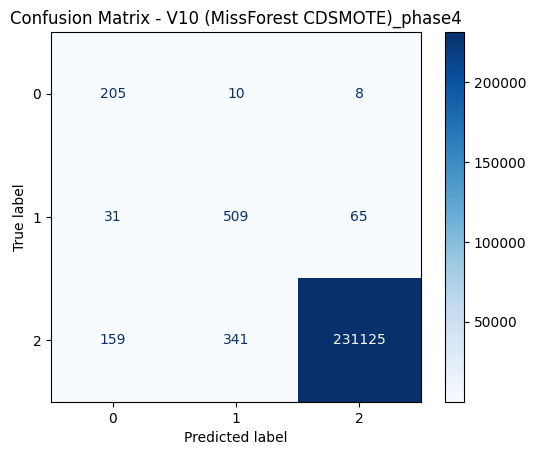

Saved confusion matrix to: results/confusion_matrix_V10 (MissForest CDSMOTE)_phase4.csv
Saved probability matrix to: results/probability_matrix_V10 (MissForest CDSMOTE)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V10 (MissForest CDSMOTE),1,170.845375,0.536976,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V10 (MissForest CDSMOTE),2,170.845375,0.594020,0.996188,0.333799,0.337703,0.992935,0.333799,0.996188,0.333699,0.994543,0.000000,0.003662,0.001836,0.000000,0.000000,0.00000,0.0000,0.016667,0.001653,0.003008,0.040651,0.996441,0.999745,0.998091,0.034748
2,V10 (MissForest CDSMOTE),3,170.845375,0.706856,0.996085,0.354097,0.412879,0.993679,0.354097,0.996085,0.365925,0.994743,0.000000,0.103900,0.076168,0.000000,0.000000,0.00000,0.0000,0.242038,0.062810,0.099738,0.250555,0.996599,0.999482,0.998038,0.214173
3,V10 (MissForest CDSMOTE),4,170.845375,0.894625,0.997359,0.919482,0.703511,0.998162,0.919482,0.997359,0.785691,0.997649,0.942749,0.719611,0.704226,0.518987,0.919283,0.66343,0.9584,0.591860,0.841322,0.694881,0.916542,0.999684,0.997841,0.998762,0.953870


In [32]:
df_v10 = run_experiment(
    base_path=base_path,
    train_file="train_extra_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V10 (MissForest CDSMOTE)"
)

df_v10

In [33]:
df_v10.to_csv("results_v10.csv", index=False)

## V11 (MissForest SASMOTE)


#####
Version: V11 (MissForest SASMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_sasmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (5791443, 179)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.554523 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 43198
[LightGBM] [Info] Number of data points in the train set: 5791443, number of used features: 179
[LightGBM] [Info] Start training from score -1.139457
[LightGBM] [Info] Start training from score -1.139251
[LightGBM] [Info] Start training from score -1.021794
Time Build Model: 173.84s

--- Test Phase 1: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_1.csv ---

============================== V11 (MissForest SASMOTE) - Phase 1 =

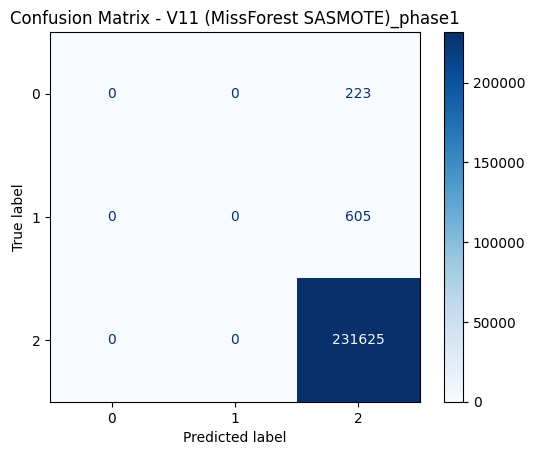

Saved confusion matrix to: results/confusion_matrix_V11 (MissForest SASMOTE)_phase1.csv
Saved probability matrix to: results/probability_matrix_V11 (MissForest SASMOTE)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_2.csv ---

============================== V11 (MissForest SASMOTE) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0000000000 0.0000000000 0.0000000000       605
     Average  0.9964379896 1.0000000000 0.9982158172    231625

    accuracy                      0.9964379896    232453
   macro avg  0.3321459965 0.3333333333 0.3327386057    232453
weighted avg  0.9928886671 0.9964379896 0.9946601621    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.0000000000
  Good      : 0.0000000000
  Average   : 0.0000000000

TimeBuildModel         : 173.8446202278
TimePredict            : 0.6111293840
Accuracy          

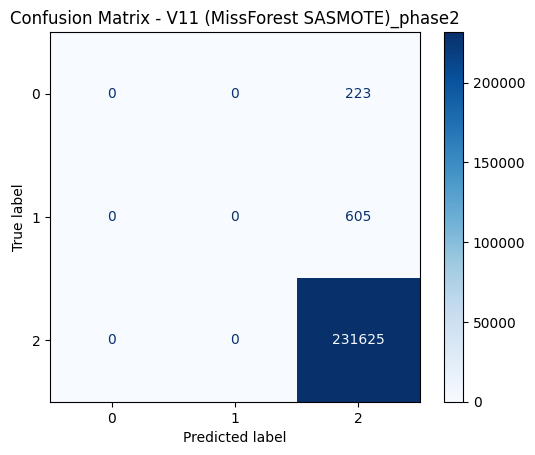

Saved confusion matrix to: results/confusion_matrix_V11 (MissForest SASMOTE)_phase2.csv
Saved probability matrix to: results/probability_matrix_V11 (MissForest SASMOTE)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_3.csv ---

============================== V11 (MissForest SASMOTE) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.5918367347 0.0479338843 0.0886850153       605
     Average  0.9965620065 0.9999093362 0.9982328653    231625

    accuracy                      0.9964724052    232453
   macro avg  0.5294662471 0.3492810735 0.3623059602    232453
weighted avg  0.9945526020 0.9964724052 0.9949079678    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.0000000000
  Good      : 0.2189286399
  Average   : 0.1871389301

TimeBuildModel         : 173.8446202278
TimePredict            : 0.7338063090
Accuracy          

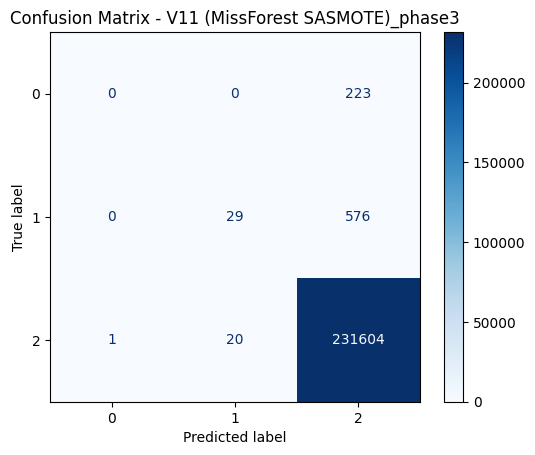

Saved confusion matrix to: results/confusion_matrix_V11 (MissForest SASMOTE)_phase3.csv
Saved probability matrix to: results/probability_matrix_V11 (MissForest SASMOTE)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_4.csv ---

============================== V11 (MissForest SASMOTE) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.5282051282 0.9237668161 0.6721044046       223
        Good  0.5853107345 0.8561983471 0.6953020134       605
     Average  0.9997145057 0.9977852132 0.9987489277    231625

    accuracy                      0.9973457000    232453
   macro avg  0.7044101228 0.9259167921 0.7887184486    232453
weighted avg  0.9981836118 0.9973457000 0.9976457924    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.9607470526
  Good      : 0.9245772233
  Average   : 0.9582544595

TimeBuildModel         : 173.8446202278
TimePredict            : 0.9018940830
Accuracy          

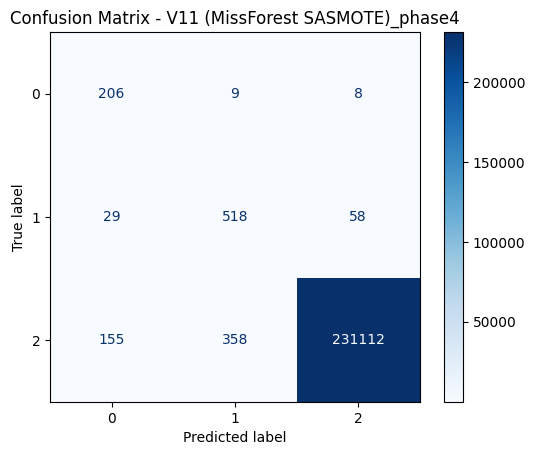

Saved confusion matrix to: results/confusion_matrix_V11 (MissForest SASMOTE)_phase4.csv
Saved probability matrix to: results/probability_matrix_V11 (MissForest SASMOTE)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V11 (MissForest SASMOTE),1,173.84462,0.552815,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V11 (MissForest SASMOTE),2,173.84462,0.611129,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
2,V11 (MissForest SASMOTE),3,173.84462,0.733806,0.996472,0.349281,0.529466,0.994553,0.349281,0.996472,0.362306,0.994908,0.000000,0.141992,0.065733,0.000000,0.000000,0.000000,0.000000,0.591837,0.047934,0.088685,0.218929,0.996562,0.999909,0.998233,0.187139
3,V11 (MissForest SASMOTE),4,173.84462,0.901894,0.997346,0.925917,0.704410,0.998184,0.925917,0.997346,0.788718,0.997646,0.947715,0.722214,0.705599,0.528205,0.923767,0.672104,0.960747,0.585311,0.856198,0.695302,0.924577,0.999715,0.997785,0.998749,0.958254


In [34]:
df_v11 = run_experiment(
    base_path=base_path,
    train_file="train_extra_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V11 (MissForest SASMOTE)"
)

df_v11

In [35]:
df_v11.to_csv("results_v11.csv", index=False)

## V12 (MissForest RadiusSMOTE)


#####
Version: V12 (MissForest RadiusSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_radiussmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Final X shape: (5791443, 179)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.489555 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 43725
[LightGBM] [Info] Number of data points in the train set: 5791443, number of used features: 179
[LightGBM] [Info] Start training from score -1.139457
[LightGBM] [Info] Start training from score -1.139251
[LightGBM] [Info] Start training from score -1.021794
Time Build Model: 152.29s

--- Test Phase 1: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_1.csv ---

============================== V12 (MissForest RadiusSMOTE)

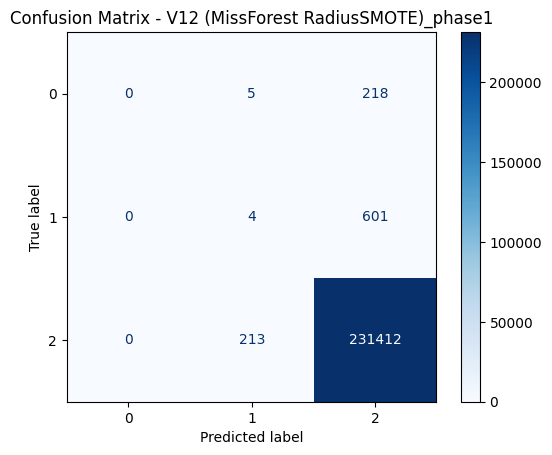

Saved confusion matrix to: results/confusion_matrix_V12 (MissForest RadiusSMOTE)_phase1.csv
Saved probability matrix to: results/probability_matrix_V12 (MissForest RadiusSMOTE)_phase1.csv

--- Test Phase 2: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_2.csv ---

============================== V12 (MissForest RadiusSMOTE) - Phase 2 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.2432432432 0.0297520661 0.0530191458       605
     Average  0.9965229216 0.9997668645 0.9981422574    231625

    accuracy                      0.9962831196    232453
   macro avg  0.4132553883 0.3431729769 0.3503871344    232453
weighted avg  0.9936063801 0.9962831196 0.9947248560    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.0000000000
  Good      : 0.1724670400
  Average   : 0.1553993503

TimeBuildModel         : 152.2889482975
TimePredict            : 0.8324323070
Accura

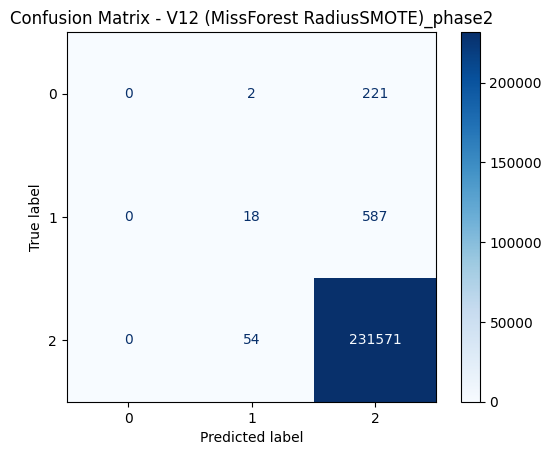

Saved confusion matrix to: results/confusion_matrix_V12 (MissForest RadiusSMOTE)_phase2.csv
Saved probability matrix to: results/probability_matrix_V12 (MissForest RadiusSMOTE)_phase2.csv

--- Test Phase 3: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_3.csv ---

============================== V12 (MissForest RadiusSMOTE) - Phase 3 ==============================
              precision    recall  f1-score   support

   Excellent  0.7209302326 0.1390134529 0.2330827068       223
        Good  0.3392461197 0.2528925620 0.2897727273       605
     Average  0.9973960916 0.9988343227 0.9981146890    231625

    accuracy                      0.9960680224    232453
   macro avg  0.6858574813 0.4635801125 0.5069900410    232453
weighted avg  0.9954179170 0.9960680224 0.9955371830    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.3728354459
  Good      : 0.5025609544
  Average   : 0.5198230936

TimeBuildModel         : 152.2889482975
TimePredict            : 0.9852181370
Accura

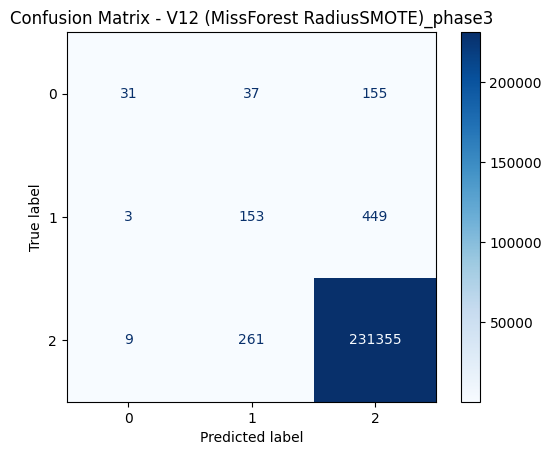

Saved confusion matrix to: results/confusion_matrix_V12 (MissForest RadiusSMOTE)_phase3.csv
Saved probability matrix to: results/probability_matrix_V12 (MissForest RadiusSMOTE)_phase3.csv

--- Test Phase 4: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_4.csv ---

============================== V12 (MissForest RadiusSMOTE) - Phase 4 ==============================
              precision    recall  f1-score   support

   Excellent  0.6366666667 0.8565022422 0.7304015296       223
        Good  0.6590214067 0.7123966942 0.6846703733       605
     Average  0.9994082048 0.9988645440 0.9991363004    231625

    accuracy                      0.9979823878    232453
   macro avg  0.7650320927 0.8559211601 0.8047360678    232453
weighted avg  0.9981742978 0.9979823878 0.9980600410    232453

G-Mean per class (one-vs-rest):
  Excellent : 0.9252568467
  Good      : 0.8436299453
  Average   : 0.9130134052

TimeBuildModel         : 152.2889482975
TimePredict            : 1.0674993440
Accura

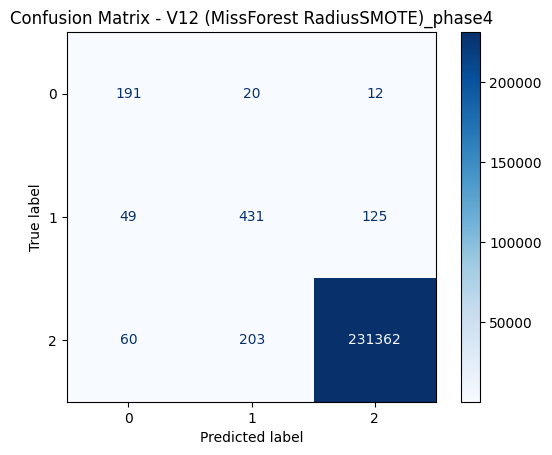

Saved confusion matrix to: results/confusion_matrix_V12 (MissForest RadiusSMOTE)_phase4.csv
Saved probability matrix to: results/probability_matrix_V12 (MissForest RadiusSMOTE)_phase4.csv


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V12 (MissForest RadiusSMOTE),1,152.288948,0.740107,0.995539,0.335231,0.338164,0.992971,0.335231,0.995539,0.335816,0.994246,0.000000,0.013591,0.011092,0.000000,0.000000,0.000000,0.000000,0.018018,0.006612,0.009674,0.081273,0.996473,0.999080,0.997775,0.104209
1,V12 (MissForest RadiusSMOTE),2,152.288948,0.832432,0.996283,0.343173,0.413255,0.993606,0.343173,0.996283,0.350387,0.994725,0.000000,0.075957,0.041644,0.000000,0.000000,0.000000,0.000000,0.243243,0.029752,0.053019,0.172467,0.996523,0.999767,0.998142,0.155399
2,V12 (MissForest RadiusSMOTE),3,152.288948,0.985218,0.996068,0.463580,0.685857,0.995418,0.463580,0.996068,0.506990,0.995537,0.460102,0.317410,0.307064,0.720930,0.139013,0.233083,0.372835,0.339246,0.252893,0.289773,0.502561,0.997396,0.998834,0.998115,0.519823
3,V12 (MissForest RadiusSMOTE),4,152.288948,1.067499,0.997982,0.855921,0.765032,0.998174,0.855921,0.997982,0.804736,0.998060,0.893231,0.737873,0.736014,0.636667,0.856502,0.730402,0.925257,0.659021,0.712397,0.684670,0.843630,0.999408,0.998865,0.999136,0.913013


In [36]:
df_v12 = run_experiment(
    base_path=base_path,
    train_file="train_extra_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V12 (MissForest RadiusSMOTE)"
)

df_v12

In [37]:
df_v12.to_csv("results_v12.csv", index=False)